![inflation image](../images/inflation_image_tissue.jpg)

<h1 style='color: skyblue'> Cost of Living: What the Headline Hides </h1>

In April 2026, the ONS reported that UK inflation had fallen to 3.0%, down from
3.4% in March — below the Bank of England's own forecast
([House of Commons Library, 2026](https://commonslibrary.parliament.uk/research-briefings/cbp-10857/)).
On the surface, good news. But a single headline figure conceals twelve very
different stories underneath it. The fall was driven mainly by a **7% cut to the
Ofgem energy price cap on 1 April**, which lowered electricity and gas costs by
about £117 per household
([MoneyWeek, 2026](https://moneyweek.com/economy/news/live/inflation-cpi-april-2026-report)) —
yet at the same time, motor fuel prices were surging by over 23% on the back
of the Middle East conflict
([ONS, 2026a](https://www.ons.gov.uk/economy/inflationandpriceindices/bulletins/consumerpriceinflation/april2026)).

So which categories were really moving the needle — and would the fall last?
This analysis breaks the headline apart to find out.

**The investigation:**
- **Q1** — Establish the headline, and whether it is high or low.
- **Q2** — Which categories are rising fastest? *(by rate)*
- **Q3** — Which categories actually hurt households most — and is that the same list? *(by weighted contribution)*
- **Q4** — What's accelerating, what's easing? *(month-on-month change)* 
- **Q6** — In pounds, where does the money go?
- **Q8** — Whose household is this, actually? 





-----
_<h2 style='color: lightblue'> _Data Load & Preview_ </h2>_


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 

In [ ]:

data = pd.read_csv('cost_of_living_merged.csv')

data.head(5)

,month,division_code,division_name,annual_rate,weight,weighted_contribution,mom_change
0,2026-Apr,4,"Housing, water, electricity, gas and other fuels",3.0,313.8,0.94,NaN
1,2026-Mar,4,"Housing, water, electricity, gas and other fuels",4.3,313.8,1.35,1.3
2,2026-May,4,"Housing, water, electricity, gas and other fuels",2.7,313.8,0.85,-1.6
3,2026-Apr,6,Health,2.4,20.7,0.05,NaN
4,2026-Mar,6,Health,3.1,20.7,0.06,0.7


<h2 style='color: skyblue'> Data Load </h2>


In [ ]:
data.shape

(36, 7)

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   month                  36 non-null     str    
 1   division_code          36 non-null     int64  
 2   division_name          36 non-null     str    
 3   annual_rate            36 non-null     float64
 4   weight                 36 non-null     float64
 5   weighted_contribution  36 non-null     float64
 6   mom_change             24 non-null     float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.2 KB


<h2 style='color: skyblue'> Data Preview </h2>


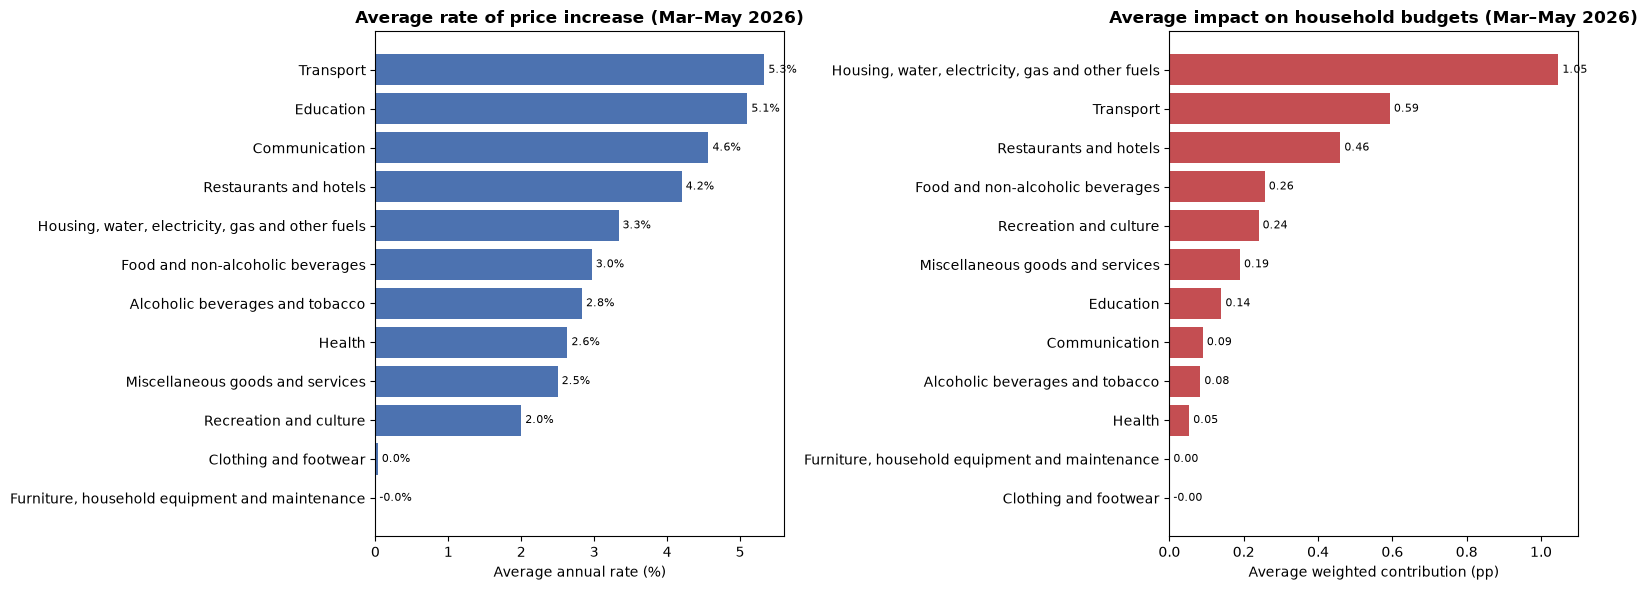

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: average rate
avg_rate = data.groupby('division_name')['annual_rate'].mean().sort_values()
ax1.barh(avg_rate.index, avg_rate.values, color='#4C72B0')
ax1.set_xlabel('Average annual rate (%)')
ax1.set_title('Average rate of price increase (Mar–May 2026)', fontweight='bold')
# label each bar
for i, v in enumerate(avg_rate.values):
    ax1.text(v, i, f' {v:.1f}%', va='center', fontsize=8)

# RIGHT: average impact
avg_impact = data.groupby('division_name')['weighted_contribution'].mean().sort_values()
ax2.barh(avg_impact.index, avg_impact.values, color='#C44E52')
ax2.set_xlabel('Average weighted contribution (pp)')
ax2.set_title('Average impact on household budgets (Mar–May 2026)', fontweight='bold')
# label each bar
for i, v in enumerate(avg_impact.values):
    ax2.text(v, i, f' {v:.2f}', va='cen' \
    'er', fontsize=8)

plt.tight_layout()
plt.show()

**This chart shows that a category's inflation rate (left) does not necessarily match its impact on a household budget (right). Transport and Education rank highest by rate, yet neither has the greatest budget impact. Housing, by contrast, ranks only fifth by rate (3.3%) but first by impact (1.05) — because housing is the largest share of household spending, even a modest price rise translates into the biggest real cost. This confirms the core finding: the fastest-rising prices are not the ones that hurt households most. Health ranks low on both rate and impact. This likely reflects its small share of household spending, as much UK healthcare is publicly funded through the NHS rather than paid directly by households.**

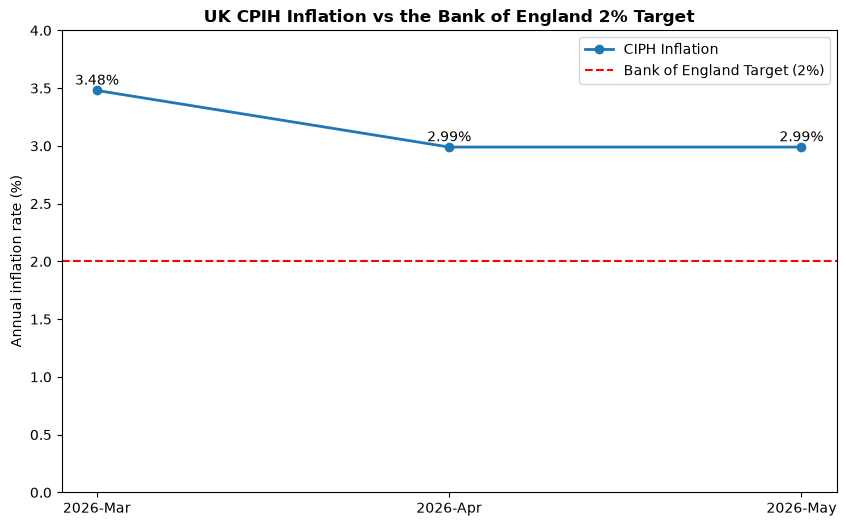

In [ ]:
month_order = ['2026-Mar', '2026-Apr', '2026-May']

headline =data.groupby('month')['weighted_contribution'].sum()

headline_ordered = headline.reindex(month_order)


plt.figure(figsize=(10, 6))
plt.plot(month_order, headline_ordered.values, marker='o', linewidth=2, label='CIPH Inflation')

plt.axhline(y=2.0, color='red', linestyle='--', label='Bank of England Target (2%)')


for month, value in zip(month_order, headline_ordered.values):
    plt.text(month, value + 0.05, f'{value:.2f}%', ha='center')


plt.title('UK CPIH Inflation vs the Bank of England 2% Target', fontweight='bold')
plt.ylabel('Annual inflation rate (%)')
plt.ylim(0, 4)
plt.legend()
plt.show()

### What the chart shows: March → April → May

Across all three months, CPIH inflation sits **above the Bank of England's 2%
target** ([Bank of England, 2026](https://www.bankofengland.co.uk/monetary-policy/inflation)),
though far below the 11.8% peak of early 2023. Inflation is easing but not yet normalised — 3.0% sits above the Bank of England's
2% target, but far below the recent peak of 9.6% in October 2022, the highest CPIH
rate in over 40 years, driven by the post-pandemic energy crisis and the war in
Ukraine ([ONS, 2023](https://www.ons.gov.uk/economy/inflationandpriceindices/bulletins/consumerpriceinflation/december2023))..

**March (3.4%) — the starting point.** The rate had climbed into March, pushed up
by **transport**, specifically motor fuels, as the Middle East conflict lifted
global oil prices. Petrol rose from about 130p per litre in February to 157p by
April ([Bank of England, 2026](https://www.bankofengland.co.uk/monetary-policy/inflation)).
Petrol reprices almost instantly at the pump, so this fed through fast.

**April (fell to 3.0%) — home energy pulled it down.** The largest downward force
came from **housing and household services** — the cost of running a home, mainly
gas and electricity — whose rate dropped from 4.3% to 3.0%. Three things pushed it
down: the **Ofgem price cap fell 7% on 1 April** (about £117 off a typical bill),
the government **removed some Renewables Obligation charges** from bills, and a
**lag effect** — suppliers had bought that gas months earlier, before the price
spike. The electricity and gas contribution actually turned *negative*, subtracting
from inflation ([ONS, 2026a](https://www.ons.gov.uk/economy/inflationandpriceindices/bulletins/consumerpriceinflation/april2026)).
Note the split: **home energy fell while car fuel kept rising** — same "energy," opposite directions.

**May (held at 3.0%) — a tug-of-war that cancelled out.** Transport surged further
(petrol high, plus Easter-timed air fares up 10.3%), which should have lifted the
headline. But **cooling food prices offset it** — supermarket discounting on meat,
cheese and vegetables, plus a high year-ago comparison, pulled food inflation down.
Up-force met down-force, so the headline stayed flat — but the *source* of pressure
had rotated from the energy bill to the petrol pump
([ONS, 2026d](https://www.ons.gov.uk/economy/inflationandpriceindices/bulletins/consumerpriceinflation/may2026)).

**What this means for a household.** The fall from 3.48% to 2.99% is not abstract. For a household spending ~£35,200 a
year, that 0.49-percentage-point drop is worth roughly **£170 a year** — the amount
the rising cost of living eased by, largely thanks to the April energy price cap.
But because prices are still *rising*, just more slowly, households are not better
off — the squeeze is simply tightening less quickly, especially where wages lag.

---

<h2 style='color: skyblue'> Intriguing Queries from the Data </h2>

_<h4 style='color: skyblue'> 1. Zooming Into the categories and what drove the annual Rates </h4>_

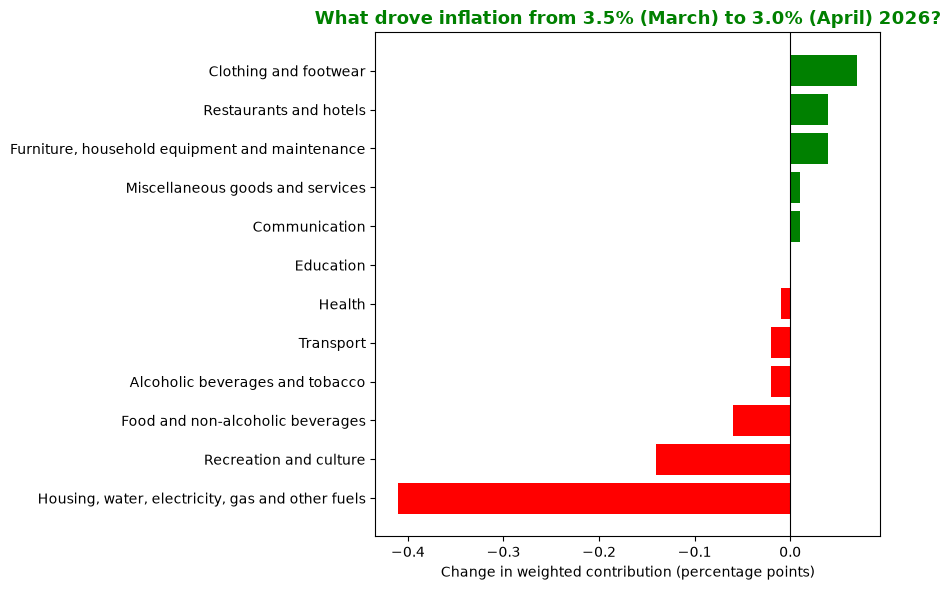

In [ ]:
#enter the 2 headlines figures for ease of data interpretation and visbility
mar_rate = headline['2026-Mar']
apr_rate = headline['2026-Apr']
may_rate = headline['2026-May']

# Sort so the chart reads cleanly, biggest faller at the bottom
movers = pivot['Mar->Apr change'].sort_values()

# Colour: red for falls (negative), green for rises (positive)
colours = ['red' if v < 0 else 'green' for v in movers.values]

plt.figure(figsize=(9, 6))
plt.barh(movers.index, movers.values, color=colours)   # barh = horizontal bars
plt.axvline(x=0, color='black', linewidth=0.8)          # the zero baseline
plt.title(f'What drove inflation from {mar_rate:.1f}% (March) to {apr_rate:.1f}% (April) 2026?', color='green', fontweight='bold', fontsize=13)
plt.xlabel('Change in weighted contribution (percentage points)')
plt.tight_layout()
plt.show()

**This chart shows what drove the headline fall from 3.4% to 3.0% in April. Housing (−0.41) was overwhelmingly the largest downward force, while every other category moved only slightly. The April fall was therefore almost entirely a housing-and-energy story — driven by the 7% cut to the Ofgem energy price cap on 1 April (ONS, 2026a). The concentration in a single category is striking: this was not a broad easing, but one category pulling the whole headline down.**

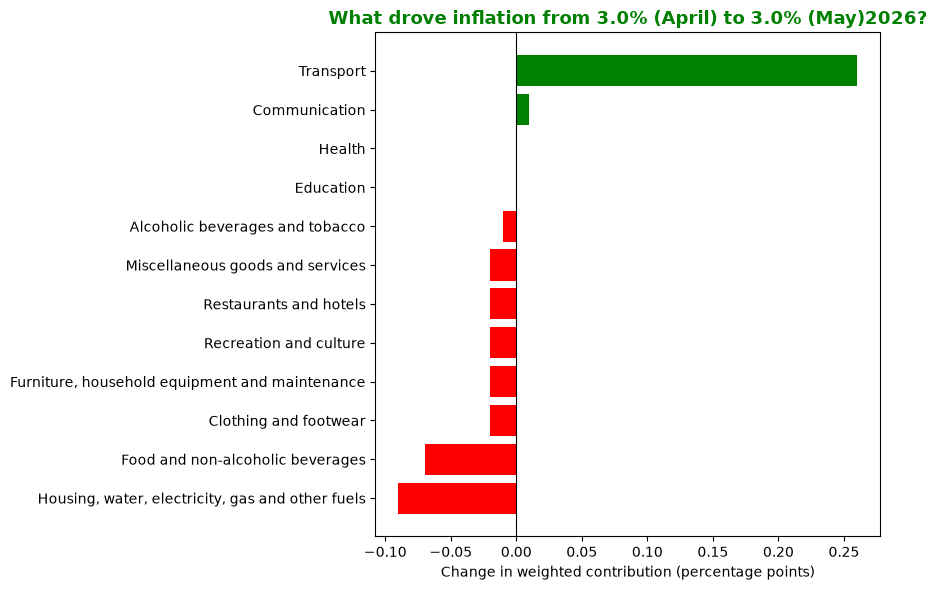

In [ ]:
# Sort so the chart reads cleanly, biggest faller at the bottom
movers = pivot['Apr->May change'].sort_values()

# Colour: red for falls (negative), green for rises (positive)
colours = ['red' if v < 0 else 'green' for v in movers.values]

plt.figure(figsize=(9, 6))
plt.barh(movers.index, movers.values, color=colours)   # barh = horizontal bars
plt.axvline(x=0, color='black', linewidth=0.8)          # the zero baseline
plt.title(f'What drove inflation from {apr_rate:.1f}% (April) to {may_rate:.1f}% (May)2026?', color='green', fontweight='bold', fontsize=13)
plt.xlabel('Change in weighted contribution (percentage points)')
plt.tight_layout()
plt.show()




**In May the headline held at 3.0%, but this chart reveals why that stability was misleading. Transport (+0.26) surged upward — driven by rising motor fuel and Easter-timed air fares — while housing and food pulled downward. The opposing forces cancelled out, holding the headline flat. The key insight: the source of inflationary pressure rotated from the energy bill to the petrol pump, a shift completely invisible in the unchanged headline number.**

_<h4 style='color: skyblue'> 2. What does it mean in pounds? </h4>_

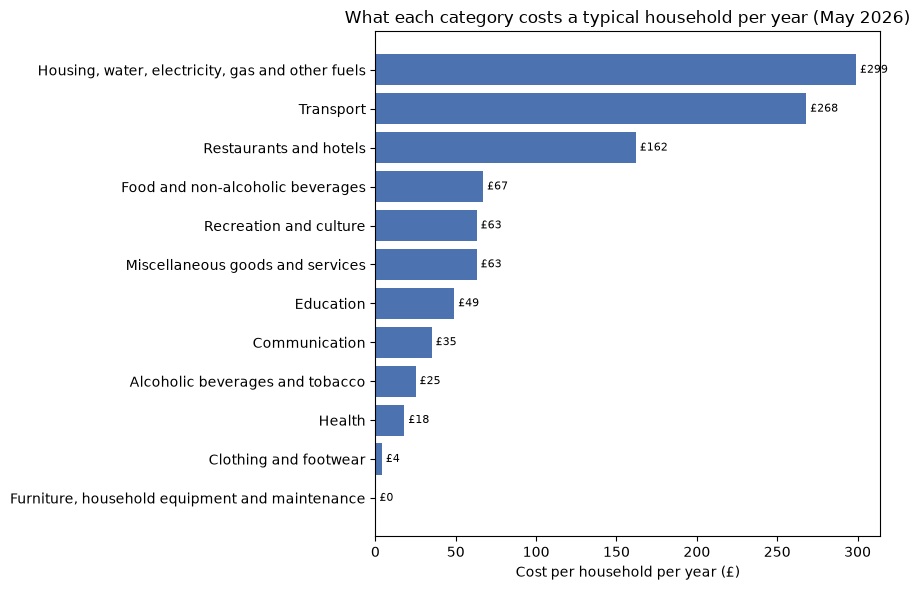

In [ ]:
household_spend = 35200
may = data[data['month'] == '2026-May'].copy()
may['pounds_per_year'] = ((may['weighted_contribution'] / 100) * household_spend).round(0)

pounds = may.sort_values('pounds_per_year').set_index('division_name')['pounds_per_year']

plt.figure(figsize=(9, 6))
plt.barh(pounds.index, pounds.values, color='#4C72B0')
plt.xlabel('Cost per household per year (£)')
plt.title('What each category costs a typical household per year (May 2026)')
for i, v in enumerate(pounds.values):
    plt.text(v, i, f' £{int(v)}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Translating each category's impact into pounds makes the abstract concrete. Housing costs a typical household around £299 a year, and transport £268 — together dwarfing communication (£35) and health (£18), despite those categories rising faster in percentage terms. This is the clearest expression of the project's core message: what a household actually feels depends on how much it spends, not how fast a price rises.**

_<h4 style='color: skyblue'> 3. Ranks per Rate and Impact </h4>_

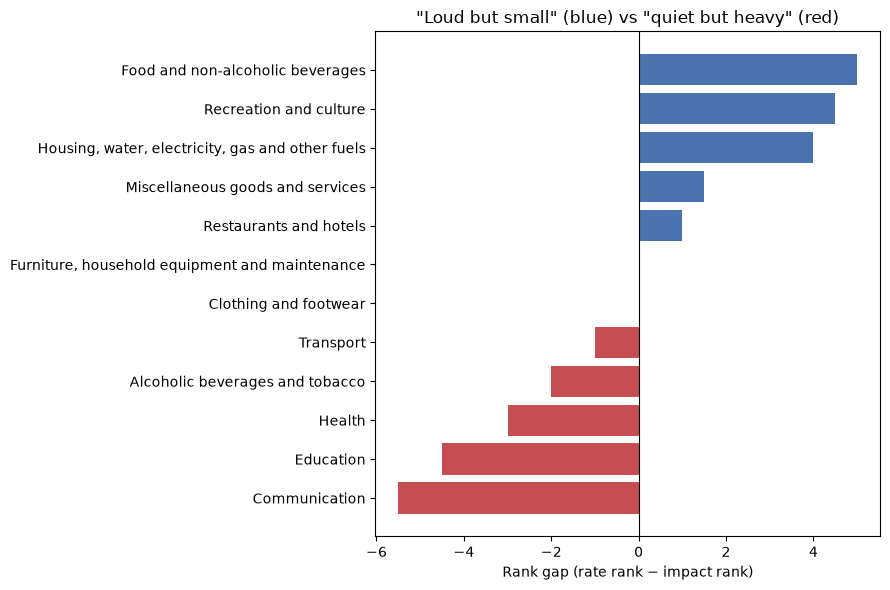

In [ ]:
may = data[data['month'] == '2026-May'].copy()
may['rank_by_rate'] = may['annual_rate'].rank(ascending=False)
may['rank_by_impact'] = may['weighted_contribution'].rank(ascending=False)
may['rank_gap'] = may['rank_by_rate'] - may['rank_by_impact']

gap = may.sort_values('rank_gap').set_index('division_name')['rank_gap']
colours = ['#C44E52' if v < 0 else '#4C72B0' for v in gap.values]

plt.figure(figsize=(9, 6))
plt.barh(gap.index, gap.values, color=colours)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Rank gap (rate rank − impact rank)')
plt.title('"Loud but small" (blue) vs "quiet but heavy" (red)')
plt.tight_layout()
plt.show()

**The rank gap measures how far each category moves between the two rankings (rate rank − impact rank). Positive (blue) categories are "quiet but heavy" — Housing and Food rise only modestly yet carry the greatest real cost, so they climb sharply from a low rate-rank to a high impact-rank. Negative (red) categories are "loud but small" — Communication and Education rise fast yet barely affect budgets, so they fall from a high rate-rank to a low impact-rank. The size of each gap quantifies the reversal: the louder the price rise, the less it often matters.**

_<h4 style='color: skyblue'> 4. Whose household is this, really? </h4>_

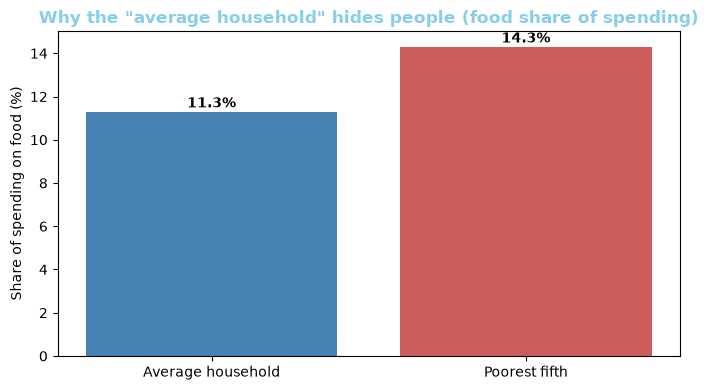

In [ ]:

household_type = ['Average household', 'Poorest fifth']
food_share = [11.3, 14.3]   # % of total spending going on food


plt.figure(figsize=(7, 4))
plt.bar(household_type, food_share, color=['steelblue', 'indianred'])
plt.title('Why the "average household" hides people (food share of spending)',
          color='skyblue', fontweight='bold', fontsize=12)
plt.ylabel('Share of spending on food (%)')
for i, v in enumerate(food_share):
    plt.text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



**This chart marks an honest limitation. The analysis describes the average household, but the poorest fifth spend a larger share of a smaller budget on essentials — 14.3% on food versus the 11.3% average. The average figure therefore understates the squeeze on low-income households. (Source: ONS Family Spending, not the 12-category dataset — this is context, not a finding from our data.)**

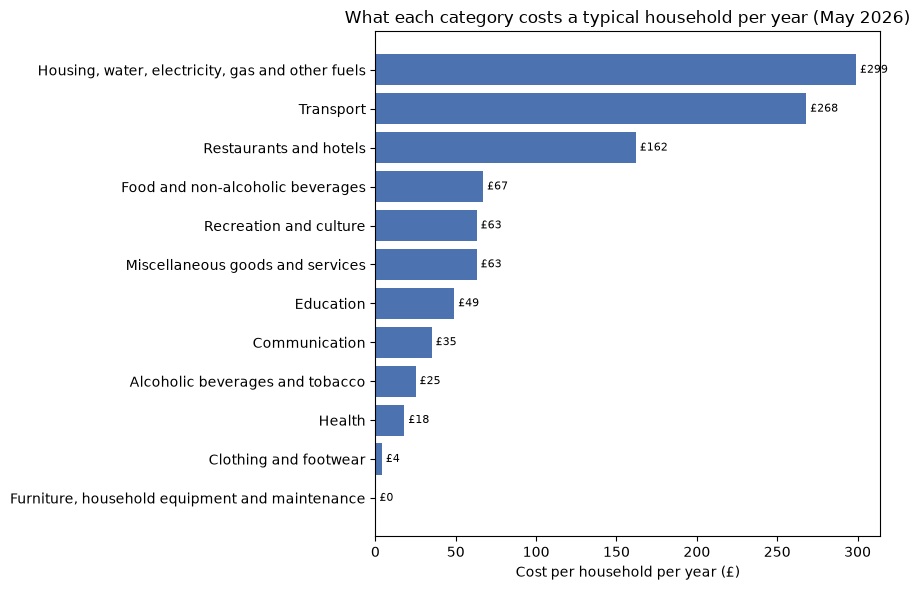

In [ ]:
household_spend = 35200
may = data[data['month'] == '2026-May'].copy()
may['pounds_per_year'] = ((may['weighted_contribution'] / 100) * household_spend).round(0)

pounds = may.sort_values('pounds_per_year').set_index('division_name')['pounds_per_year']

plt.figure(figsize=(9, 6))
plt.barh(pounds.index, pounds.values, color='#4C72B0')
plt.xlabel('Cost per household per year (£)')
plt.title('What each category costs a typical household per year (May 2026)')
for i, v in enumerate(pounds.values):
    plt.text(v, i, f' £{int(v)}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

----

![inflation image](../images/markus-spiske-j2s9TffBQLk-unsplash.jpg)


__<h1 style='color: skyblue'> Conclusion  </h1>__

This analysis set out to test a single idea: that the fastest-rising prices are not the ones that hurt households most. The data confirms it. Transport and education rose fastest by rate, yet housing — rising only modestly — carried the greatest impact on household budgets, because it is the largest share of spending.

Tracked across March to May 2026, the source of inflationary pressure rotated: energy pulled the headline down in April (following the Ofgem price-cap cut), while transport pushed it up in May — a shift invisible in the unchanged headline figure. In cash terms, housing cost a typical household roughly £299 in May — nearly nine times communication's £35 — despite communication rising faster in percentage terms.

The analysis also acknowledges its limit: it describes the average household, and the poorest fifth — who spend more of a smaller budget on essentials — feel this pressure more acutely than the average suggests. Extending the work with the ONS Household Costs Indices would address this.